# Introduction to Quality Control & Process Improvement
## Dr. Austin Brown
## School of Data Science & Analytics

In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "tcarver9"

## Set web address to forked repository (change to your own):

repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

if(!dir.exists("STAT-7110-Quality-Control")) {
  system(paste0("git clone ", repo_address))
} else {
  print("Repository already cloned to Colab.")
}

## Set working drive to today's lecture:

#setwd("Slides//Week-1-Intro-to-Quality-Control")

## Table of Contents

1. What is quality?
2. The DMAIC Process
3. The "Magnificent 7"
4. Control Chart Basics
5. Introduction to Shewhart-style Charts

---

## What is Quality?

- Quality is a word we hear all the time, but what does it mean to you?

    - In terms of a product? In terms of a service? In terms of software/user interfaces?

- We can define quality in a few different ways. First, we can examine quality in terms of its dimensions:

    1. *Performance* (Will the product/service do what it's supposed to do?)
    2. *Reliability* (Does the product/service consistently do what it's supposed to do?)
    3. *Durability* (How long does the product/service last?)
    4. *Serviceability* (Is it easy to fix (if it's a product) or have your problems solved (if it's a service)?)
    5. *Aesthetics* (What is the visual appeal of the product/service?)
    6. *Features* (What does the product/service do?)
    7. *Perceived Quality* (What is the reputation of the product/company?)
    8. *Conformance to Standards* (Is the product made exactly how the designer intended?)

- For services specifically, there are three additional dimensions we can consider:

    9. *Responsiveness* (How quickly does the organization address your concerns?)
    10. *Professionalism* (Does the organization have the knowledge and skills to perform the service? Additionally, do they treat you with care and have professional appearance both physically and in communication?)
    11. *Attentiveness* (Are my needs being personally met and do I feel like I'm being "taken care of?")

---

- As we go through all of these dimensions of quality, we can see that quality centers around this idea of "fitness of use."

- When we think about quality in this way, we can see that in order for an organization to have a quality product or service, that we have to have quality in both the design stage (engineering designs, app mock-up, service plan etc.) as well as in the on-line stage (manufacturing, app goes live, store opens up etc.)

    - Obviously these two things go hand in hand

- If we have well-designed a product or process, then in the on-line phase when we're manufacturing the product or running our service business, we would *generally* say that we have a quality product or service when it varies little from the initial design.

- In other, more statistical language, quality is the inverse of variability and thus, **quality monitoring and improvement** is the systematic monitoring of and reduction of variability in a process.

## Why Should I Care About Quality?

- Quality failures are expensive in ways that go beyond the obvious:

    - **Product recalls cost real money.** When a defect reaches the customer, the price tag includes recalls, repairs, legal liability, and regulatory fines, all of which dwarf the cost of catching the problem earlier.

    - **Poor service drives customers away permanently.** In industries like telecom, streaming, or banking, a bad experience doesn't just lose a sale, it sends customers to competitors and fuels negative reviews that compound over time.

    - **Reputational damage spreads faster than ever.** Social media means a quality failure can go viral within hours. Boeing's 737 MAX crisis and Samsung's Galaxy Note 7 recall are recent examples of how quality issues can threaten an entire brand.

    - **Regulators are paying closer attention.** In healthcare, food, financial services, and tech, quality failures increasingly trigger government scrutiny, fines, or mandatory audits (e.g., FDA warning letters, GDPR penalties).

    - **Employees and talent notice too.** Organizations known for shoddy work struggle to attract top talent. Quality culture is now part of employer brand.

## The DMAIC Process

- A key component of ensuring quality is by having a structured approach to problem-solving and process evaluation, monitoring, and improvement.

    - One of my favorite quotes: *"Goals are for people who care about winning once. Systems are for people who care about winning repeatedly."* - James Clear, author of *Atomic Habits*

- A structured approach, while borne in a manufacturing environment, is also at the core of effective **Data/AI Governance**.

    - Lots of seemingly new ideas are just old ideas with a fresh haircut!

- One of the most famous structured approaches is the DMAIC process, which stands for Define, Measure, Analyze, Improve, and Control.

### The DMAIC Process: The Define Phase

- The first step in DMAIC is deceptively simple: **know what you're trying to improve and why it matters.**

- Before any data is collected or statistics are run, the Define phase establishes:
    - **What process** is being monitored
    - **What "good" looks like** (the quality standard you're aiming for)
    - **What supporting processes** feed into the primary one

#### A Running Example: The Coffee Shop ☕

- Let's use a coffee shop as our working example. Suppose our goal is to ensure customers consistently receive a high-quality cup of coffee.

- That sounds simple, but quality coffee depends on a web of upstream processes:

    > *What are all the things that have to go right for a customer to leave satisfied?*

- We'll map these out using a **process flowchart**, which is a core Define-phase tool. This gives everyone a shared picture of what the process actually looks like before we start measuring anything.

#### Quality Programs Don't Run Themselves

- Even a perfectly designed quality program can fail if the people involved aren't on board.

- A critical (and often overlooked) part of the Define phase is **organizational buy-in**:

    - Workers at every level need to understand *why* the program is being introduced
    - Resistance or indifference on the floor (or in the back office) will undermine even the best statistical methods
    - The **Define** phase is where you make the case, clearly and convincingly, for why this effort is worth everyone's time

- This is sometimes called a **change management** challenge as much as a technical one. The statistics can be sound; the harder problem is often human. Two things to remember:

    > 1. *Trust is built through consistent actions and transparent communication.*
    
    > 2. *Feedback is a gift. Build feedback loops with decision-makers and people who will be impacted by the changes.*

## The DMAIC Process: The Measure Phase

- With the process defined, the Measure phase answers two questions: **what do we measure, and how do we measure it?**

- This introduces one of the core concepts in quality control: **quality characteristics (QCs)**. QCs are observable, operationalized indicators of whether a process is performing well. QCs come in two flavors:

| Type | Description | Coffee Shop Example |
|---|---|---|
| **Variable** | A quantitative measurement | Brew temperature (°F), wait time (minutes) |
| **Attribute** | A categorical judgment | Satisfied / Unsatisfied, Pass / Fail |

- Going back to our process flowchart, the Measure phase asks us to annotate each node: *what gets measured here, and how?*

---

### The Measure Phase as a Research Design Problem

- If you've taken a research methods course, this will feel familiar. The Measure phase is essentially:

1. **What is my research question?** (defined in the previous phase)
2. **What variables are indicators of process quality?**
3. **What data will I collect, and how will I collect it?**

- Vague operationalization is one of the most common reasons quality programs fail. If "good coffee" isn't defined in measurable terms, there's nothing concrete to improve.

---

## The DMAIC Process: The Analyze Phase

- With data in hand, the Analyze phase is where we dig in. Here, we use statistical tools to **identify sources of variability** in the process.

- The toolkit is broad and depends on the nature of your data and process:
    - Histograms and run charts for visualizing distributions over time
    - Regression analysis for understanding relationships between variables
    - Factorial designs for isolating the effect of multiple factors at once

- But regardless of the tool, the core goal is the same: find out *why* the process varies, and distinguish between two fundamental types of causes:

| Cause Type | What It Means | Implication |
|---|---|---|
| **Common cause** | Variability baked into the process itself | Requires a systemic fix |
| **Assignable cause** | Variability tied to a specific, identifiable event | Can be traced and corrected |

---

### Analyzing Our Coffee Shop Data

- Recall that we're collecting daily customer satisfaction responses via a yes/no email survey. Each response is timestamped and stored in a database.

> *Pause and think: what statistical tool(s) would be appropriate for analyzing this type of data over time?*

- We're dealing with a **binary attribute** (satisfied / not satisfied) aggregated daily. This should start to suggest a particular family of control charts we'll explore later.

---

## The DMAIC Process: The Improve Phase

- If the Analyze phase surfaces a problem, the Improve phase asks: **what do we change, and how?**

- This requires both statistical thinking *and* creative problem-solving. Even in manufacturing, a process running out of spec can have many competing root causes.

---

### Tool: The Five Why's

- Suppose we notice that the proportion of customers dissatisfied with our coffee's taste has been trending upward over the past month. A simple but powerful diagnostic tool here is **the Five Why's**: iteratively asking "why?" until you reach a root cause rather than a symptom.

**Example chain:**

1. *Why are more customers dissatisfied with the taste?* → The coffee tastes more bitter than usual.
2. *Why does it taste more bitter?* → The brew temperature has been running high.
3. *Why is the brew temperature high?* → The thermostat on the new machine wasn't calibrated.
4. *Why wasn't it calibrated?* → There was no onboarding checklist for new equipment.
5. *Why is there no checklist?* → Equipment setup has always been handled informally.

**Root cause:** Lack of a standardized equipment setup process — something a checklist or SOP can fix.

![Five Whys Diagram](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-1-Intro-to-Quality-Control/5-whys-examples.jpg)

- Other angles worth examining in our coffee example: a new supplier, a change in beans, new staff who weren't adequately trained, or a change in the water source. The Five Why's helps you avoid fixing the wrong thing.

---

### A Note on "Done"

- There is no finish line in the Improve phase. A few reasons why:

    - Processes drift over time, and what worked last year may need revisiting
    - Customer expectations evolve — quality is a moving target (the cassette player that once signaled a premium car is now a curiosity)
    - External factors — new suppliers, staff turnover, regulatory changes — introduce new variation

- The goal of the Improve phase is to get the process working the way you want it to work **right now**, so you have a stable baseline to monitor going forward.

---

## The DMAIC Process: The Control Phase

- The Control phase is where everything comes together. Once the process is improved and stable, the goal shifts to **detecting when it stops behaving the way it should.**

- This is the primary job of a **control chart**: a graphical and statistical tool that distinguishes between normal process variation and a signal that something has gone wrong (i.e., the process has gone "out of control").

- We'll dig into the anatomy of control charts shortly, but it's worth stepping back to appreciate why every prior phase matters:

> Skipping steps in DMAIC doesn't save time. Rather, it means you risk having the right answer to the wrong question, or the wrong answer to the right question. We call this a Type III error in statistical consulting.

- A control chart is only as meaningful as the measurement system behind it, which is only as meaningful as the process definition behind *that*. The phases are a chain, not a checklist.

## The Magnificient 7

- While the focus of this class will largely be on control charts, there are other graphical methods for analyzing and improving processes.

- Some you are likely already familiar with, but the ones primarily used in process improvement are referred to as the "Magnificent 7" and include:

### A Histogram

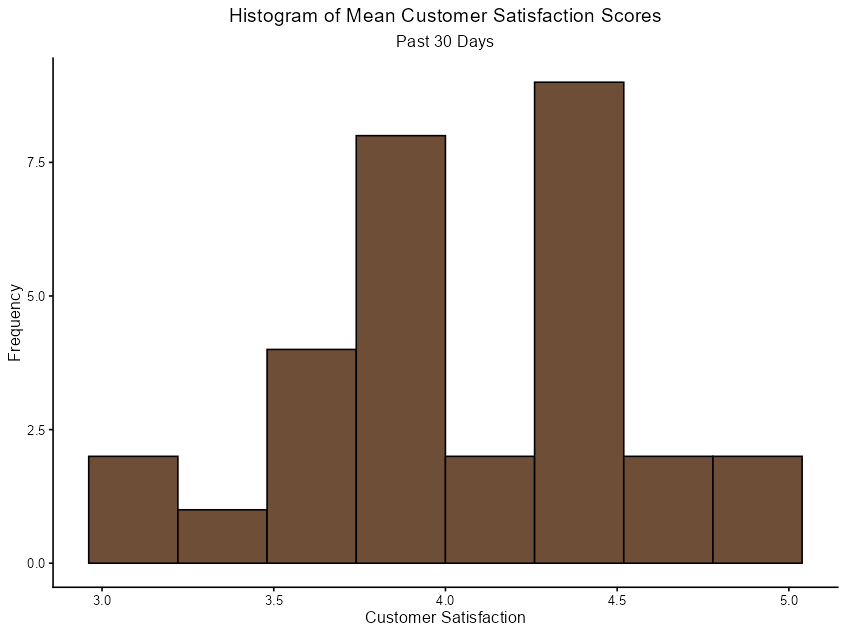

In [ ]:
## Set Seed for Reproducability ##
set.seed(12345)
## Install and load tidyverse ##
install.packages("tidyverse")
library(tidyverse)

## Generate 30 random customer satisfaction scores
## from a normal distribution with mean=4 and sd=0.5,
## and truncate any scores above 5 to 5 ##

cs <- tibble(Score = abs(rnorm(30,mean=4,sd=0.5)))
cs <- cs |>
  mutate(Score = if_else(Score > 5, 5, Score))

## Generate Histogram ##

cs |>
  ggplot(aes(x=Score)) +
  geom_histogram(aes(y=after_stat(count)),
                 bins=8,
                 fill = "#6F4E37",
                 color = "black") +
  labs(x = "Customer Satisfaction",
       y = "Frequency",
       title = "Histogram of Mean Customer Satisfaction Scores",
       subtitle = "Past 30 Days") +
  theme_classic() +
  theme(plot.title=element_text(hjust=0.5),
        plot.subtitle=element_text(hjust=0.5)
      )

### A Check Sheet

![Check Sheet](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-1-Intro-to-Quality-Control/CheckSheet.JPG)

### A Pareto Chart

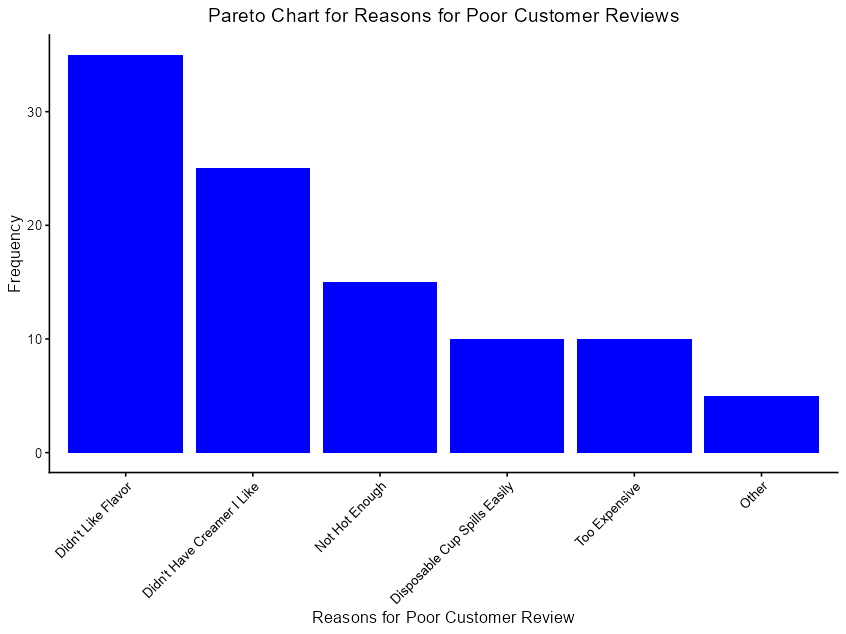

In [ ]:
css <- tibble(Reasons = c(

  rep("Didn't Like Flavor",35),
  rep("Didn't Have Creamer I Like",25),
  rep("Not Hot Enough",15),
  rep("Too Expensive",10),
  rep("Disposable Cup Spills Easily",10),
  rep("Other",5)

  )

)

freqz <- css |>
  count(Reasons) |>
  arrange(desc(n)) |>
  mutate(cumulative = cumsum(n))

freqz |>
  ggplot(aes(x=reorder(Reasons, -n),y=n)) +
  geom_bar(fill="blue",stat="identity") +
  labs(x="Reasons for Poor Customer Review",
       y="Frequency",
       title="Pareto Chart for Reasons for Poor Customer Reviews") +
  theme_classic() +
  theme(plot.title=element_text(hjust=0.5),
        axis.text.x=element_text(angle=45,hjust=1)
  )

### A Cause and Effect Sheet

![Cause and Effect Sheet](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-1-Intro-to-Quality-Control/CauseandEffect.JPG)

### A Defect Concentration Diagram

![Defect Concentration Diagram](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-1-Intro-to-Quality-Control/DefectConcentrationDiagram.png)

### A Scatterplot

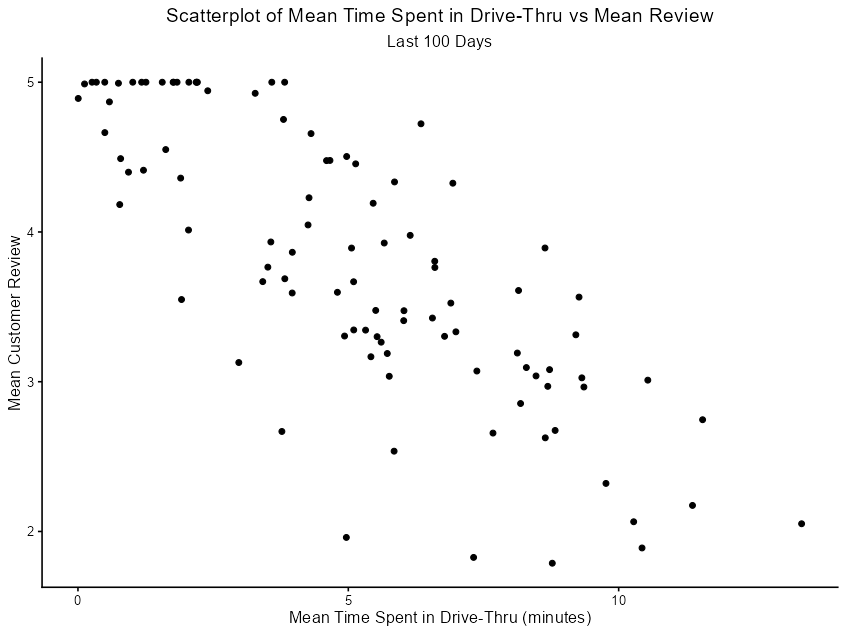

In [ ]:
df <- abs(MASS::mvrnorm(
  100,
  c(5,4),
  matrix(c(9,-2.25,-2.25,1),
  ncol=2)
  )
)

df <- as_tibble(df)

names(df) <- c("Time in Drive-Thru","Customer Review")

df <- df |>
  mutate(`Customer Review` =
    if_else(`Customer Review` > 5, 5, `Customer Review`))

df |>
  ggplot(aes(x=`Time in Drive-Thru`,y=`Customer Review`)) +
  geom_point() +
  labs(x="Mean Time Spent in Drive-Thru (minutes)",
       y="Mean Customer Review",
       title="Scatterplot of Mean Time Spent in Drive-Thru vs Mean Review",
       subtitle="Last 100 Days") +
  theme_classic() +
  theme(plot.title=element_text(hjust=0.5),
        plot.subtitle=element_text(hjust=0.5)
  )

### A Control Chart

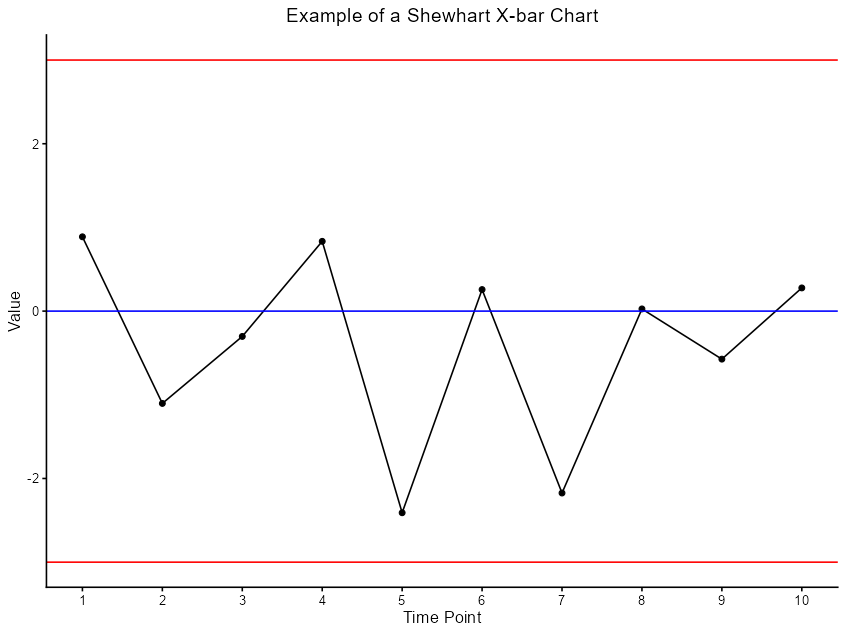

In [ ]:
xbar <- tibble(value = rnorm(10),
               time = 1:10
)

xbar |>
  ggplot(aes(x=time,y=value)) +
  geom_point(color='black') +
  geom_line(color='black') +
  geom_hline(yintercept=3,color='red') +
  geom_hline(yintercept=-3,color='red') +
  geom_hline(yintercept=0,color='blue') +
  labs(x="Time Point",
       y="Value",
       title = "Example of a Shewhart X-bar Chart") +
  theme_classic() +
  theme(plot.title=element_text(hjust=0.5)) +
  scale_x_continuous(n.breaks=10)

## Elements of a Control Chart

- Every control chart, regardless of the type of process being monitored, shares three core components:

| Component | Description |
|---|---|
| **Plotting Statistic** | A summary statistic computed from a sample taken at a specific point in time |
| **Target Value** | The ideal value of the monitored characteristic. This is either known theoretically or estimated from historical data |
| **Control Limit(s)** | Thresholds analogous to critical values in hypothesis testing — if a plotting statistic exceeds a control limit, the process is flagged as potentially out of control |

- If you look at the Shewhart $\bar{X}$-Chart example above, you can identify all three of these elements in action.

---

### When Is a Control Chart Used?

- Control charts are typically deployed in the **Control phase** of DMAIC — after the process has already been stabilized and shown to be **capable** (i.e., it can consistently meet quality targets when running as intended).

- At that point, the control chart serves as an ongoing monitoring tool. Any signal, which is defined as a plotting statistic crossing a control limit, is interpreted as evidence that something *new* may have entered the process.

---

### Two Types of Signals

- When a control chart flags a deviation from target, there are two possible explanations:

| Signal Type | Analogy | What It Means | Goal |
|---|---|---|---|
| **Random cause** | Type I error | The chart flagged out-of-control by chance, but the process is actually fine | Minimize false alarms |
| **Assignable (non-random) cause** | True positive | Something real and correctable has happened | Detect it as quickly as possible |

- This creates a fundamental design tension for any control chart:

1. **Don't cry wolf** — false alarms are costly and erode trust in the monitoring system
2. **Don't miss real signals** — a true process shift should be caught quickly before defects accumulate

---

### Looking Ahead

- Balancing these two goals is what drives the statistical design of control charts. Throughout this course, we'll cover several chart types. Each is suited to a particular kind of process or quality characteristic.

- We'll discuss how to choose the right one for a given situation.